# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Cargar dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalización
x_train, x_test = x_train / 255.0, x_test / 255.0

# Data Augmentation Layer
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


## Definiciones de modelos

In [2]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.

# --- Arquitectura 1: CNN Básica ---
model_1 = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# --- Arquitectura 2: CNN Robusta (Con Regularización) ---
model_2 = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# --- Arquitectura 3: Transfer Learning (MobileNetV2) ---
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False # Congelamos la base

model_tl = models.Sequential([
    layers.UpSampling2D((3,3)), # MobileNetV2 prefiere imágenes más grandes
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/tmp/ipykernel_7438/3972499926.py:36: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Entrenamiento de modelos.

In [3]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
models_list = [model_1, model_2, model_tl]
histories = []
names = ["CNN Básica", "CNN Robusta", "Transfer Learning"]

for i, model in enumerate(models_list):
    print(f"Entrenando {names[i]}...")
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10,
                        validation_data=(x_test, y_test), verbose=1)
    histories.append(history)

Entrenando CNN Básica...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 32ms/step - accuracy: 0.4241 - loss: 1.6031 - val_accuracy: 0.5272 - val_loss: 1.3152
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.5315 - loss: 1.3210 - val_accuracy: 0.5972 - val_loss: 1.1314
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 31ms/step - accuracy: 0.5642 - loss: 1.2281 - val_accuracy: 0.6066 - val_loss: 1.0922
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.5905 - loss: 1.1642 - val_accuracy: 0.6282 - val_loss: 1.0581
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.6048 - loss: 1.1220 - val_accuracy: 0.6202 - val_loss: 1.0909
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.6171 - loss: 1.0875 - val_accuracy: 0.6451 - val_loss: 1.0296
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6258 - loss: 1.0612 - val_accuracy: 0.6416 - val_loss: 1.0365
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/

ValueError: Input 0 with name 'input_layer' of layer 'mobilenetv2_1.00_224' is incompatible with the layer: expected shape=(None, 32, 32, 3), found shape=(None, 96, 96, 3)

## Estadística y gráficos

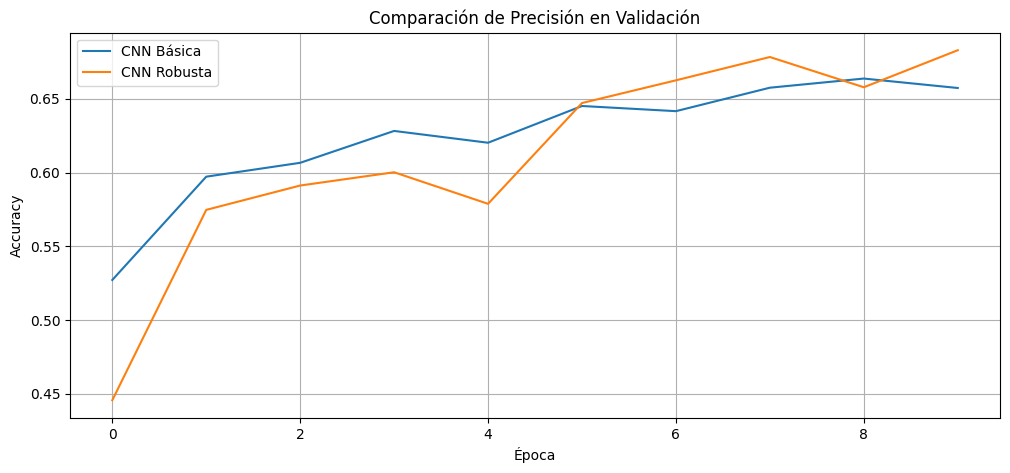

CNN Básica - Precisión Final: 0.6573
CNN Robusta - Precisión Final: 0.6829


ValueError: Input 0 with name 'input_layer' of layer 'mobilenetv2_1.00_224' is incompatible with the layer: expected shape=(None, 32, 32, 3), found shape=(None, 96, 96, 3)

In [4]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
plt.figure(figsize=(12, 5))

for i, history in enumerate(histories):
    plt.plot(history.history['val_accuracy'], label=names[i])

plt.title('Comparación de Precisión en Validación')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Resumen de resultados finales
for i, model in enumerate(models_list):
    res = model.evaluate(x_test, y_test, verbose=0)
    print(f"{names[i]} - Precisión Final: {res[1]:.4f}")

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?